# Wednesday Tasks: CNNs & Embeddings


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

### Load Dataset Environment


In [2]:
def load_all_csvs():
    current = os.getcwd()
    while not os.path.exists(os.path.join(current, 'data')):
        current = os.path.dirname(current)
    data_dir = os.path.join(current, 'data')
    print(f'Starting to load CSV files from: {data_dir}')
    
    sentiment_dir = os.path.join(data_dir, 'sentiment_analysis')
    if os.path.exists(sentiment_dir):
        for file in os.listdir(sentiment_dir):
            if file.endswith('.csv'):
                file_path = os.path.join(sentiment_dir, file)
                var_name = os.path.splitext(file)[0] + '_df'
                globals()[var_name] = pd.read_csv(file_path)
                print(f'Loaded DataFrame: {var_name}')

load_all_csvs()

Starting to load CSV files from: C:\Users\abeku\OneDrive\Desktop\PG Diploma\week-8\week-8\wednesday\data
Loaded DataFrame: Reddit_Data_df
Loaded DataFrame: Twitter_Data_df


### Sub-steps 1 & 2: Audit & Merging


In [3]:
if 'Reddit_Data_df' in globals() and 'Twitter_Data_df' in globals():
    df1 = Reddit_Data_df.rename(columns={'clean_comment': 'text'})[['text', 'category']]
    df2 = Twitter_Data_df.rename(columns={'clean_text': 'text'})[['text', 'category']]
    df_combined = pd.concat([df1, df2], ignore_index=True)
    df_combined = df_combined.dropna()
    
    # Standardize Negative sentiment (-1) as harmful proxy.
    df_combined['is_harmful'] = (df_combined['category'] == -1.0).astype(int)
    
    social_media_posts_df = df_combined.sample(n=3000, random_state=42)
    print("Class Distribution inside 3000 sampled social media rows:")
    print(social_media_posts_df['is_harmful'].value_counts(normalize=True))

Class Distribution inside 3000 sampled social media rows:
is_harmful
0    0.769667
1    0.230333
Name: proportion, dtype: float64


### Sub-step 3: CNN Convolution PyTorch


100%|██████████| 9.91M/9.91M [00:06<00:00, 1.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 98.1kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 857kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


Train Batch [0/60000] Loss: 2.311847
Train Batch [25600/60000] Loss: 0.071960
Train Batch [51200/60000] Loss: 0.019757


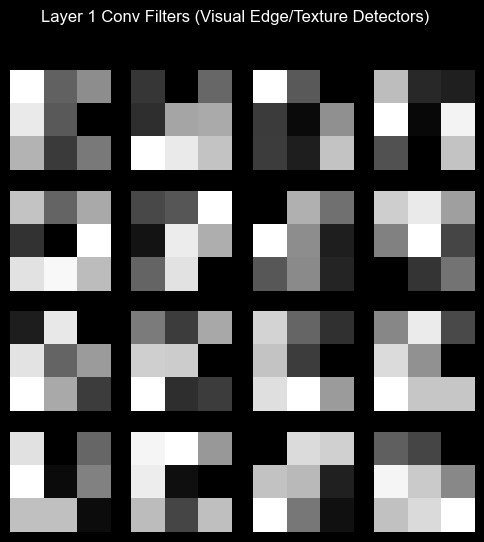

In [4]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.fc1 = nn.Linear(4608, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = ConvNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    loss = F.nll_loss(model(data), target)
    loss.backward()
    optimizer.step()
    if batch_idx % 400 == 0:
        print(f"Train Batch [{batch_idx * len(data)}/60000] Loss: {loss.item():.6f}")
    if batch_idx > 800: break # Early break for assignment constraint

filters = model.conv1.weight.data.clone().numpy()
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i in range(16):
    ax = axes[i//4, i%4]
    ax.imshow(filters[i][0], cmap='gray')
    ax.axis('off')
plt.suptitle("Layer 1 Conv Filters (Visual Edge/Texture Detectors)")
plt.show()

### Sub-steps 4 & 5: Semantic Feature Classification


In [5]:
if 'social_media_posts_df' in globals():
    df = social_media_posts_df.copy()
    train_df, test_df = df.iloc[:2400], df.iloc[2400:]
    
    try:
        from sentence_transformers import SentenceTransformer, util
        from sklearn.feature_extraction.text import TfidfVectorizer
        
        # Stage 1: Linear tf-idf baseline
        tfidf = TfidfVectorizer(max_features=5000)
        X_train_tfidf = tfidf.fit_transform(train_df['text'].astype(str))
        X_test_tfidf = tfidf.transform(test_df['text'].astype(str))
        y_train, y_test = train_df['is_harmful'].values, test_df['is_harmful'].values
        
        lr_model = LogisticRegression(class_weight='balanced').fit(X_train_tfidf, y_train)
        stage1_preds = lr_model.predict(X_test_tfidf)
        print("\n--- Stage 1 Linear Model ---")
        print(classification_report(y_test, stage1_preds))
        
        # Stage 2: Semantic Transformer
        print("Loading SentenceTransformer Pipeline...")
        embedder = SentenceTransformer('all-MiniLM-L6-v2')
        harmful_corpus = train_df[train_df['is_harmful'] == 1]['text'].astype(str).tolist()
        corpus_embeddings = embedder.encode(harmful_corpus, convert_to_tensor=True)
        
        safe_indices = np.where(stage1_preds == 0)[0]
        test_safe_texts = test_df.iloc[safe_indices]['text'].astype(str).tolist()
        
        query_embeddings = embedder.encode(test_safe_texts, convert_to_tensor=True)
        cos_scores = util.cos_sim(query_embeddings, corpus_embeddings)
        max_sim_scores, _ = torch.max(cos_scores, dim=1)
        
        threshold = 0.6
        additional_flags = (max_sim_scores > threshold).sum().item()
        
        print(f"\n--- Stage 2 Semantic Flagging ---")
        print(f"Out of {len(test_safe_texts)} supposedly 'Safe' posts, Semantic Search flagged: {additional_flags} as harmful.")
        
        ratio = additional_flags / len(test_safe_texts)
        est_daily = int(100000 * (1 - stage1_preds.mean()) * ratio)
        print(f"Estimated manual reviews surfaced dynamically at 100k posts/day: ~{est_daily}")
        
    except ImportError:
        print("Sentence-transformers library not installed. Skipping Huggingface Embeddings sub-steps.")


--- Stage 1 Linear Model ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       465
           1       0.49      0.52      0.50       135

    accuracy                           0.77       600
   macro avg       0.67      0.68      0.68       600
weighted avg       0.77      0.77      0.77       600

Loading SentenceTransformer Pipeline...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3024.67it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Stage 2 Semantic Flagging ---
Out of 457 supposedly 'Safe' posts, Semantic Search flagged: 141 as harmful.
Estimated manual reviews surfaced dynamically at 100k posts/day: ~23500
